ML - supervised unsupervised semi-supervised RL
problems - classification regression

classificaiton  -- p(labels or class , yes no , true false )
regresion  -- p(continuous val) , linear regression  - simple , multiple . obj - best fit line . ( line of minimal error ) - gradient  descent (minimize cost function - totl err . mini err function )


salary prediction model
using linear regression

evaluae regression model

reg tech - polynomial regrsson




In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print ("imported")

imported


In [7]:
data = pd.read_csv("salary_data.csv")
data.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [ ]:
data.shape

(30, 2)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [ ]:
data.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


assumption of linear regression - that there exists a liear relation exists between x and y

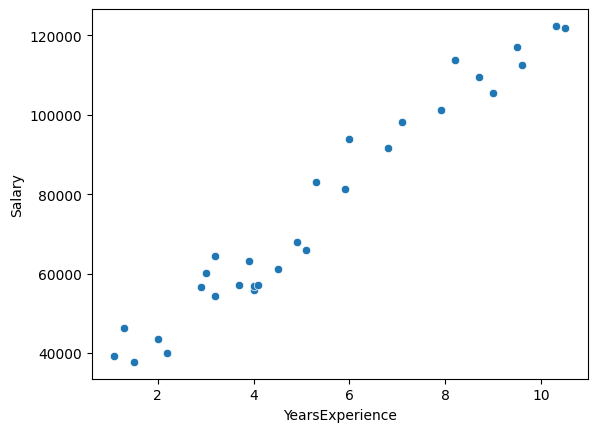

In [ ]:
sns.scatterplot(x = "YearsExperience", y = "Salary", data = data)
plt.show()


<Axes: xlabel='YearsExperience', ylabel='Salary'>

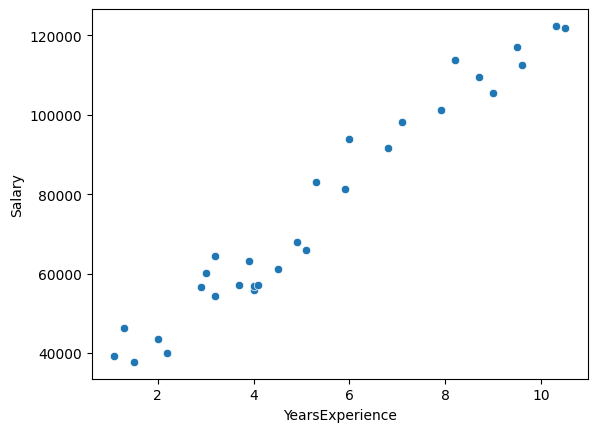

In [ ]:
sns.scatterplot(x=data["YearsExperience"], y=data["Salary"] )

task - explore all kinds of plots in sns


Supported Data Formats
- Long-form or Wide-form DataFrames:
This is the standard pandas DataFrame format (e.g., sns.lineplot(data=df, x="column1", y="column2")).

- Numpy Arrays: You can pass 1D or 2D numpy arrays directly to the data parameter or to specific axes (e.g., sns.histplot(numpy_array)).

- Python Lists / Tuples: Standard Python lists of numbers work perfectly fine for quick, single-variable plots (e.g., sns.boxplot(x=[1, 2, 3, 4, 5])).

- Pandas Series: Individual columns extracted from a DataFrame can be passed directly into the mapping variables (e.g., sns.scatterplot(x=df['age'], y=df['salary'])).

Flexible Ways to Pass Data

The Object-Oriented Approach (Using a DataFrame):You pass the
DataFrame to the data argument, and use string names for the axes.

sns.scatterplot(data=my_dataframe, x="age", y="fare")


---


The Direct Vector Approach (Without a DataFrame):You pass raw data arrays (lists, series, or numpy arrays) directly into the axes arguments without using the data parameter at all.

age_list = [22, 38, 26, 35]
fare_list = [7.25, 71.28, 7.92, 53.10]

sns.scatterplot(x=age_list, y=fare_list)



Seaborn (sns) organizes its plotting functions into three main modules based on the type of data analysis you are doing, along with a few **specialized structural and regression plots.**
Most plots come in two forms: **a figure-level function **(which creates its own window/grid) and **an axes-level function **(which draws onto a specific subplot).
------------------------------
## 1. Relational Plots (Visualizing Relationships)
These plots help you see how two or more numeric variables relate to one another.

*
* sns.scatterplot() (Axes-level) / sns.relplot(kind="scatter") (Figure-level): Draws individual data points to show correlations.
* sns.lineplot() (Axes-level) / sns.relplot(kind="line") (Figure-level): Connects data points chronologically or sequentially, ideal for time-series data.
*

## 2. Distribution Plots (Visualizing Data Spread)
These plots show how your data is distributed, helping you identify skewness, outliers, and peaks.

*
* sns.histplot() (Axes-level) / sns.displot(kind="hist") (Figure-level): A classic histogram that counts data frequency within specific ranges (bins).
* sns.kdeplot() (Axes-level) / sns.displot(kind="kde") (Figure-level): Kernel Density Estimate plot, which creates a smooth, continuous curve representing the data probability.
* sns.ecdfplot() (Axes-level) / sns.displot(kind="ecdf") (Figure-level): Empirical Cumulative Distribution Function, showing the proportion of data below a certain value.
* sns.rugplot() (Axes-level): Places ticks along the axis lines to show the exact location of individual data points.
*

## 3. Categorical Plots (Comparing Groups)
Used when one of your main variables is divided into discrete categories or groups (like "Gender", "City", or "Day").

*
* Categorical Scatter Plots:
* sns.stripplot() / sns.catplot(kind="strip"): Plots all data points across categories, introducing slight jitter so overlapping points are visible.
   * sns.swarmplot() / sns.catplot(kind="swarm"): Similar to a strip plot, but automatically adjusts points so they don't overlap, resembling a swarm.
* Categorical Distribution Plots:
* sns.boxplot() / sns.catplot(kind="box"): Displays the five-number summary (minimum, 25th percentile, median, 75th percentile, and maximum) alongside outliers.
   * sns.violinplot() / sns.catplot(kind="violin"): Combines a box plot with a KDE plot to show the density shape of the data within categories.
   * sns.boxenplot() / sns.catplot(kind="boxen"): An enhanced box plot optimized for larger datasets to show more quantiles.
* Categorical Estimate Plots:
* sns.barplot() / sns.catplot(kind="bar"): Computes an aggregate estimate (usually the mean) and draws a bar with error marks.
   * sns.pointplot() / sns.catplot(kind="point"): Uses points and connecting lines instead of full bars to show changes in estimates across categories.
   * sns.countplot() / sns.catplot(kind="count"): A special bar plot that simply counts the number of occurrences in each category.
*

## 4. Regression Plots (Trend Lines)
These add automatic linear regression lines to help you instantly spot data trends.

*
* sns.regplot() (Axes-level): Plots data points and fits a linear regression trend line.
* sns.lmplot() (Figure-level): Combines regplot capabilities with the ability to split trends across a multi-plot grid.
* sns.residplot() (Axes-level): Plots the residuals (errors) of a linear regression to check if a linear model is appropriate.
*

## 5. Matrix Plots (Grids and Heatmaps)
These take 2D arrays or wide-form data to visualize large tables of numbers all at once.

*
* sns.heatmap(): Colors a grid based on the underlying cell values, widely used to visualize correlation matrices (df.corr()).
* sns.clustermap(): Hierarchically clusters rows and columns together, grouping similar data trends together visually.
*

## 6. Multi-Plot Grids (Advanced Layouts)
Instead of drawing a single chart, these function as wrappers to compare multiple variations of your data in a grid.

*
* sns.pairplot(): Automatically creates a matrix of charts showing the pairwise relationships between every single numeric column in your data.
* sns.jointplot(): Combines a bivariate plot (like a scatter plot) with univariate marginal plots (like histograms) on the top and right margins.
*

Which specific dataset or columns are you exploring right now? If you share your goal, I can tell you which plot will represent your data best and give you the code block to build it.



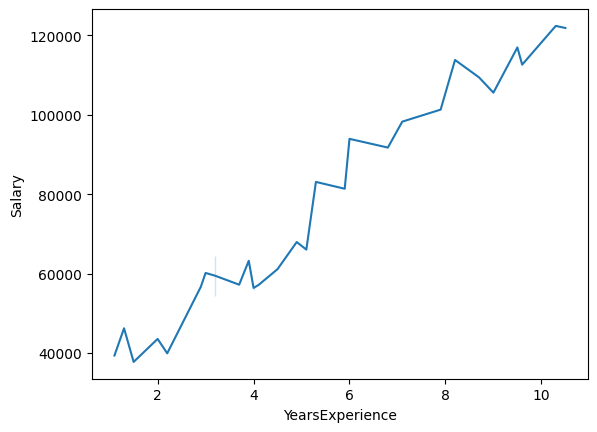

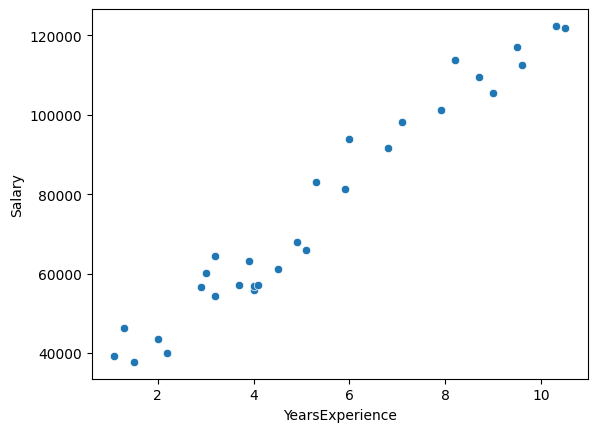

In [15]:
sns.lineplot(x = "YearsExperience", y = "Salary", data = data)
plt.show()
sns.scatterplot(x = "YearsExperience", y = "Salary", data = data)
plt.show()

steps to follow in ML projects (pre-processing)


create independent and dependent variables

split dataset . ie. training data and test data

encoding of convert categorical variable into numerical one

perform the normalization  / scaling

apply ML algorithm (lineat reg / classifiation) ie. train the model

predict model

eval of model'

save model

deployment of model







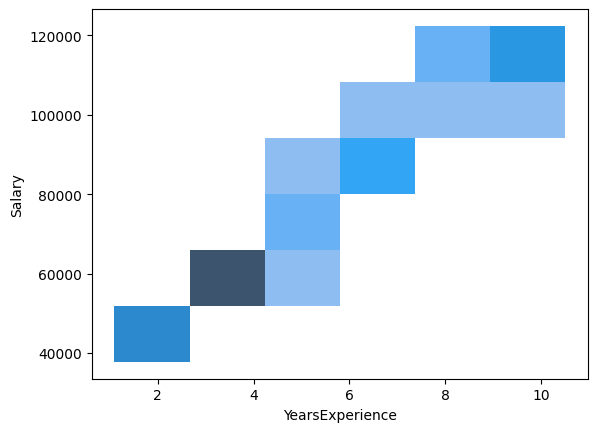

In [21]:
sns.histplot(data = data, x = "YearsExperience", y = "Salary")
plt.show()
plt.show()


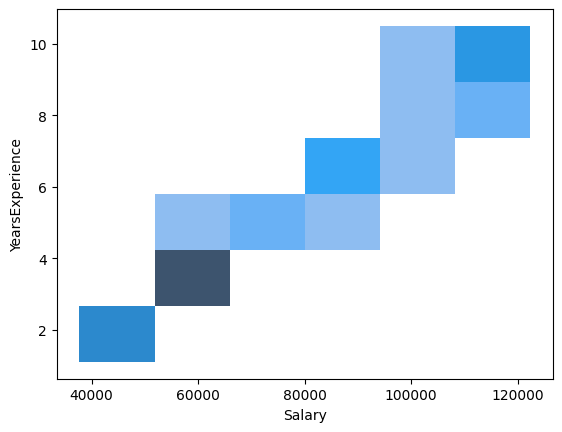

In [23]:
sns.histplot(data = data, x = "Salary" , y = "YearsExperience")
plt.show()

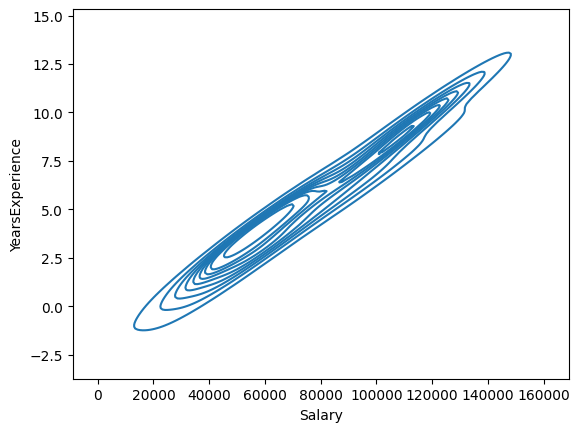

In [24]:
sns.kdeplot(data = data, x = "Salary" , y = "YearsExperience")
plt.show()

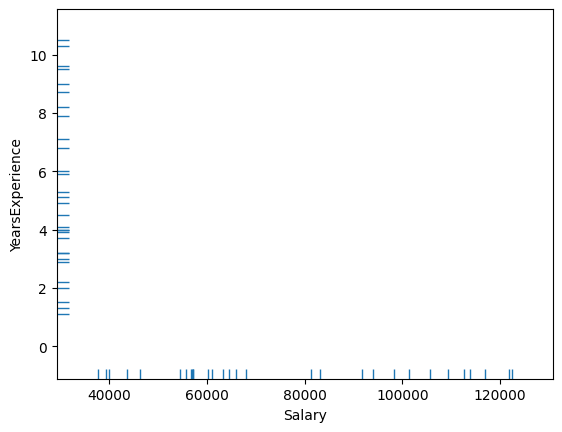

In [26]:
sns.rugplot(data = data, x = "Salary" , y = "YearsExperience")
plt.show()

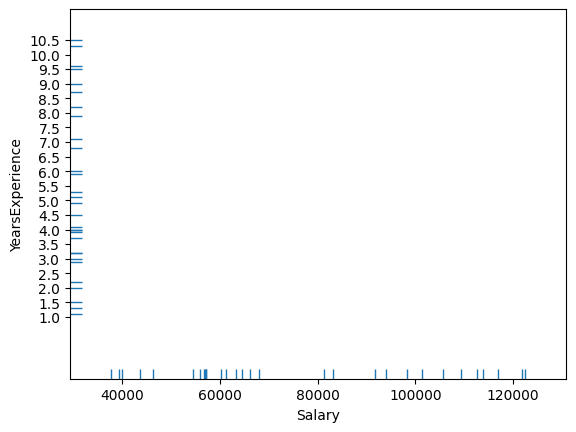

In [29]:
sns.rugplot(data = data, x = "Salary" , y = "YearsExperience")
plt.yticks(np.arange(1,11,0.5))
plt.show()